**1. Setup and Imports**

In [44]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


**2. The Abstract Problem Interface**

In [45]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


**3. The Node Class**

In [46]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


**4. Helper Functions**

In [47]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """Return True if state already appears on the path from the root to node."""
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


**5Grid Problem**

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
from abc import ABC, abstractmethod
from dataclasses import dataclass


MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

class GridProblem(Problem):
    def __init__(
        self, grid: List[List[int]], start: Tuple[int, int], goal: Tuple[int, int]
    ):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
         # TODO1: Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO2: Return a list of legal action names.
        legal_actions = []
        row, col = state
        for action, (row_dir, col_dir) in MOVES.items():
            next_state = (row + row_dir, col + col_dir)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO3: Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self, state: Tuple[int, int], action: str, next_state: Tuple[int, int]
    ) -> float:
        # TODO4: In this lab, each valid move has a cost of 1.
        return 1.0


**5.1 SELF-CHECK FOR GRIDPROBLEM**

In [49]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))
assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1
print("GridProblem self-check passed.")


GridProblem self-check passed.


**6. SAMPLE DRONE MAP**

In [50]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]
start = (0, 0)
goal = (9, 9)
problem = GridProblem(sample_grid, start, goal)


**7. Visualisation Helper**

In [51]:
import numpy as np
import matplotlib.pyplot as plt
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


**8. THE SHARED EXPAND METHOD**

In [52]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO5: Implement the AIMA-style EXPAND(problem, node).
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


**9. BREADTH-FIRST SEARCH (BFS)**

In [53]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        nodes_expanded = 0
        max_frontier_size = 1

        start_state = problem.initial_state()
        initial_node = Node(state=start_state)

        if problem.is_goal(start_state):
            return SearchResult(algorithm, "success", initial_node, 0, 1, 1)

        # TODO 6: Implement BFS graph search using a FIFO queue.
        frontier = deque([initial_node])
        reached = {start_state}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            if len(frontier) > max_frontier_size:
                max_frontier_size = len(frontier)

        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))

**10. DEPTH-FIRST SEARCH (DFS)**

In [54]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 1

        start_state = problem.initial_state()
        initial_node = Node(state=start_state)

        if problem.is_goal(start_state):
            return SearchResult(algorithm, "success", initial_node, 0, 1, 1)

        # TODO7: Implement DFS graph search using a stack.
        frontier = [initial_node]
        reached = {start_state}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem, node))
            for child in reversed(children):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            if len(frontier) > max_frontier_size:
                max_frontier_size = len(frontier)

        return SearchResult(
            algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached)
        )


**11. DEPTH-LIMITED SEARCH (DLS)**

In [55]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"
        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO8: Implement recursive depth-limited search.
        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            new_stack_size = current_stack_size + 1
            if new_stack_size > metrics["max_stack_size"]:
                metrics["max_stack_size"] = new_stack_size

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=new_stack_size,
            )

            if status == "success":
                return result, "success"
            elif status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"





**12. ITERATIVE DEEPENING SEARCH (IDS)**

In [56]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        total_nodes_expanded = 0
        absolute_max_stack = 0
        iteration_log = []

        # TODO9: Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            total_nodes_expanded += result.nodes_expanded
            if result.max_frontier_size > absolute_max_stack:
                absolute_max_stack = result.max_frontier_size

            iteration_log.append(
                {
                    "limit": limit,
                    "status": result.status,
                    "nodes_expanded": result.nodes_expanded,
                }
            )

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=absolute_max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=absolute_max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=absolute_max_stack,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )


**13. Run the Algorithms on the Sample Map**

In [57]:

bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)



,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


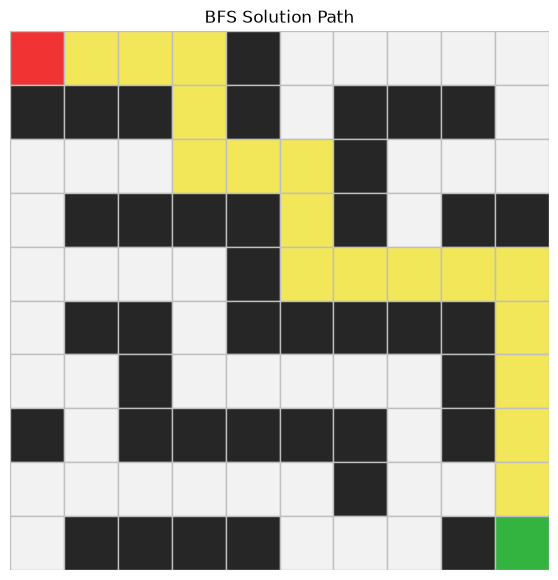

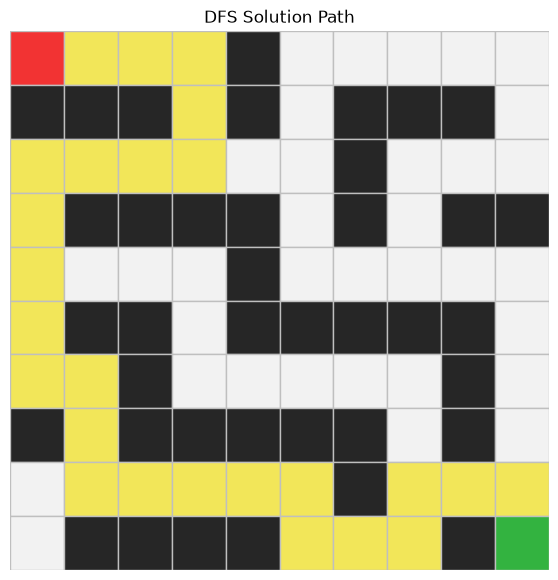

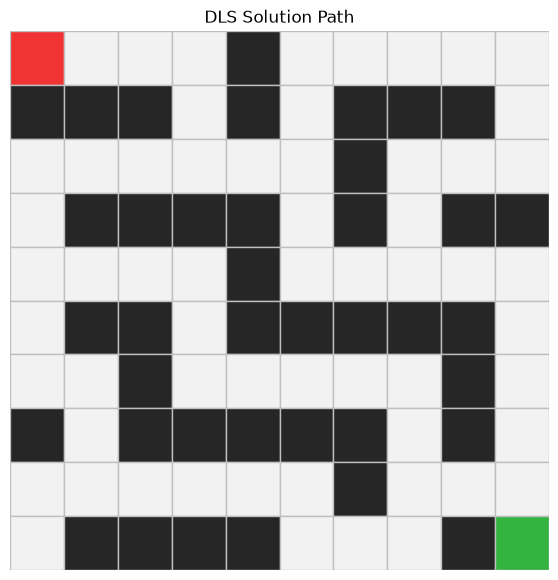

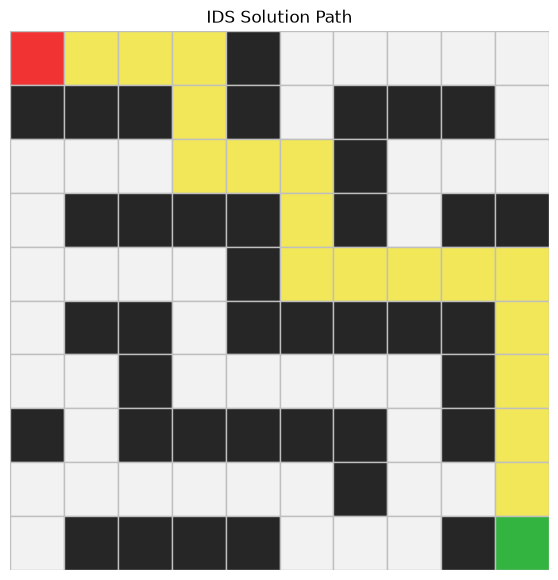

In [58]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]
dls_result = results[2]
ids_result = results[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dls_result.path,
    title="DLS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="IDS Solution Path",
)


**14. Create My Own Maps**

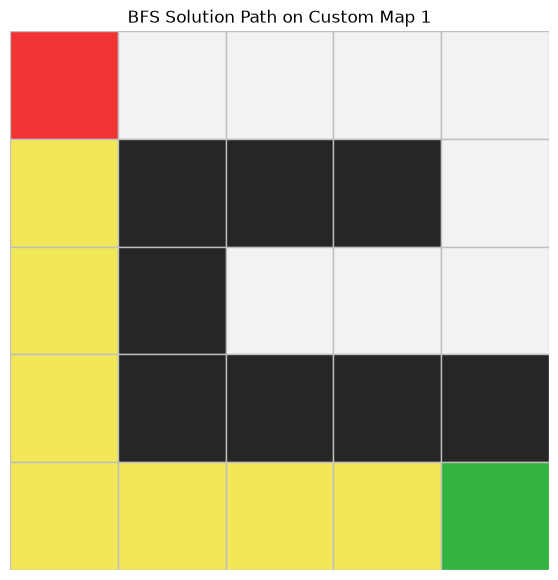

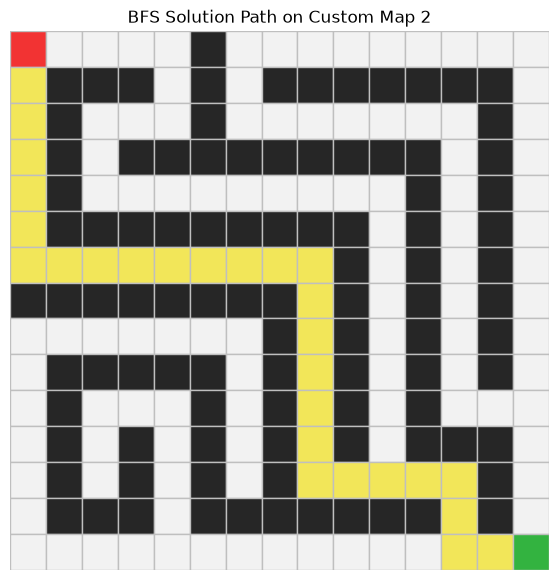

All classes, tasks, and custom environments built successfully.


In [60]:
# TODO10: Creating my first custom map here.
custom_grid_1 = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
]
custom_start_1 = (0, 0)
custom_goal_1 = (4, 4)
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

bfs_result_custom_1 = bfs.search(custom_problem_1)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result_custom_1.path,
    title="BFS Solution Path on Custom Map 1",
)

show_results([bfs_result_custom_1])

# TODO11: Create my second custom map here (15x15 Corridor Map).
custom_grid_2 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]
custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
bfs_result_custom_2 = bfs.search(custom_problem_2)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result_custom_2.path,
    title="BFS Solution Path on Custom Map 2",
)
show_results([bfs_result_custom_2])

print("All classes, tasks, and custom environments built successfully.")
